# ANALYSE DES DONNEES : ACP ET CLUSTERING

In [1]:
#Importation des librairies
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# Application du style Seaborn à tout le notebook
sns.set()

## 1. ACP

### Calcul

In [2]:
#Chargement du fichier
df_final = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\df_final.csv")

In [3]:
#Mise en page DataFrame pour ACP
df = df_final.set_index('Zone')
cols = ["Nombre d'habitants",'Consommation de viande de volailles (kg/personne/an)',"Taux d'exportation",'Taux de dépendance aux importations','Score de stabilité politique','Indice de performance logistique','PIB par habitant (en $US)','Climat des affaires','Distance avec la France (en km)']
df = df[cols]
df.head()

,Nombre d'habitants,Consommation de viande de volailles (kg/personne/an),Taux d'exportation,Taux de dépendance aux importations,Score de stabilité politique,Indice de performance logistique,PIB par habitant (en $US),Climat des affaires,Distance avec la France (en km)
Zone,,,,,,,,,
Afrique du Sud,57009756.0,35.69,2.97,24.27,59.355008,3.775321,6618.335083,65.40686,8597.536521
Albanie,2884169.0,16.36,0.00,80.85,68.692869,2.412498,5006.360130,64.16093,1553.903054
Algérie,41389189.0,6.38,0.00,0.72,50.016967,2.769683,4554.667540,46.10981,1999.581925
Allemagne,82658409.0,19.47,37.15,48.42,77.889508,4.225967,45553.934150,79.55430,758.772770
Angola,29816766.0,10.56,0.00,86.83,56.717910,2.241183,2790.718869,37.65132,6686.604478


In [4]:
#Séparation des données avec X qui correspond à la matrice des données : 
X = df.values
X[:5]

array([[5.70097560e+07, 3.56900000e+01, 2.97000000e+00, 2.42700000e+01,
        5.93550083e+01, 3.77532100e+00, 6.61833508e+03, 6.54068600e+01,
        8.59753652e+03],
       [2.88416900e+06, 1.63600000e+01, 0.00000000e+00, 8.08500000e+01,
        6.86928685e+01, 2.41249800e+00, 5.00636013e+03, 6.41609300e+01,
        1.55390305e+03],
       [4.13891890e+07, 6.38000000e+00, 0.00000000e+00, 7.20000000e-01,
        5.00169672e+01, 2.76968300e+00, 4.55466754e+03, 4.61098100e+01,
        1.99958193e+03],
       [8.26584090e+07, 1.94700000e+01, 3.71500000e+01, 4.84200000e+01,
        7.78895081e+01, 4.22596700e+00, 4.55539341e+04, 7.95543000e+01,
        7.58772770e+02],
       [2.98167660e+07, 1.05600000e+01, 0.00000000e+00, 8.68300000e+01,
        5.67179099e+01, 2.24118300e+00, 2.79071887e+03, 3.76513200e+01,
        6.68660448e+03]])

In [5]:
#Enregistrement des noms de pays dans une variable names et des noms de colonnes dans une variable features
names = df.index
features = df.columns

In [6]:
#Instanciation, fit puis transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.00808781,  1.0543171 , -0.29934969, -0.29344846, -0.42534037,
         1.26644162, -0.49972345,  0.0075272 ,  0.82915325],
       [-0.2881466 , -0.36021834, -0.34973599,  0.84675518,  0.24493653,
        -1.01145623, -0.57699834, -0.09196269, -0.9828481 ],
       [-0.07740502, -1.09053721, -0.34973599, -0.76802951, -1.09563025,
        -0.41443743, -0.59865159, -1.53337916, -0.86819552],
       [ 0.14846529, -0.132634  ,  0.28051699,  0.19322382,  0.90507653,
         2.0196763 ,  1.36677208,  1.13722736, -1.18739837],
       [-0.14074197, -0.78465215, -0.34973599,  0.96726451, -0.61463278,
        -1.29780161, -0.68321179, -2.20880577,  0.33755876]])

In [7]:
#on attend un moyenne de 0 et un écart-type à 1 : 
idx = ["mean","std"]
pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
#Instanciation de l'ACP puis entraînement sur les données scalées 
n_components = 9
pca = PCA(n_components=n_components)
pca.fit(X_scaled)

,n_components,9
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [9]:
#Variance captée par chaque composante
pca.explained_variance_ratio_

array([0.38597741, 0.16354559, 0.12357725, 0.11164683, 0.07529503,
       0.0491337 , 0.04570161, 0.02952714, 0.01559545])

La première composante capte 39% de la variance environ, puis la deuxième 16%, la troisième 12%, ...

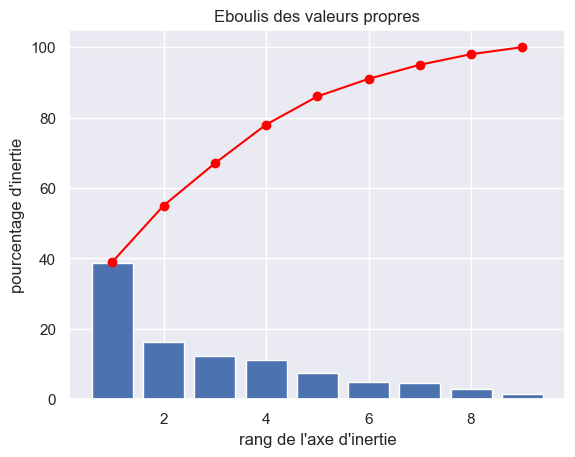

In [10]:
#Visualisation de la variance captée par les composantes
##Enregistrement des variances captées par composante
scree = (pca.explained_variance_ratio_*100).round(2)
#Calcul de la somme cumulée des variances
scree_cum= scree.cumsum().round()
##Définition d'une variable avec la liste des composantes
x_list=range(1,n_components+1)
list(x_list)
##Visualisation par un éboulis des valeurs propres
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

In [11]:
#Critère de Kaiser (on ne retient que les axes dont l'inertie associée est inférieure à (100/p)% avec p = nombre de variables)
kaiser = 100/9
nb_composante = len(scree[scree > kaiser])
print(f"Nombre de composantes à retenir selon le critère de Kaiser : {nb_composante}")

Nombre de composantes à retenir selon le critère de Kaiser : 4


Au vu de ces éléments, il semblerait que l'analyse de 4 composantes permette de conserver suffisamment d'informations tout en diminuant les dimensions.
Cela est vérifiable par plusieurs méthodes : 
- Méthode empirique : les 4 premières composantes captent environ 80% de la variance
- Méthode de Kaiser : Selon ce critère, on ne retient que les 4 premières composantes

### Cercle des corrélations

In [12]:
#Fonction permettant d'afficher le cercle des corrélations
def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an)) 

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

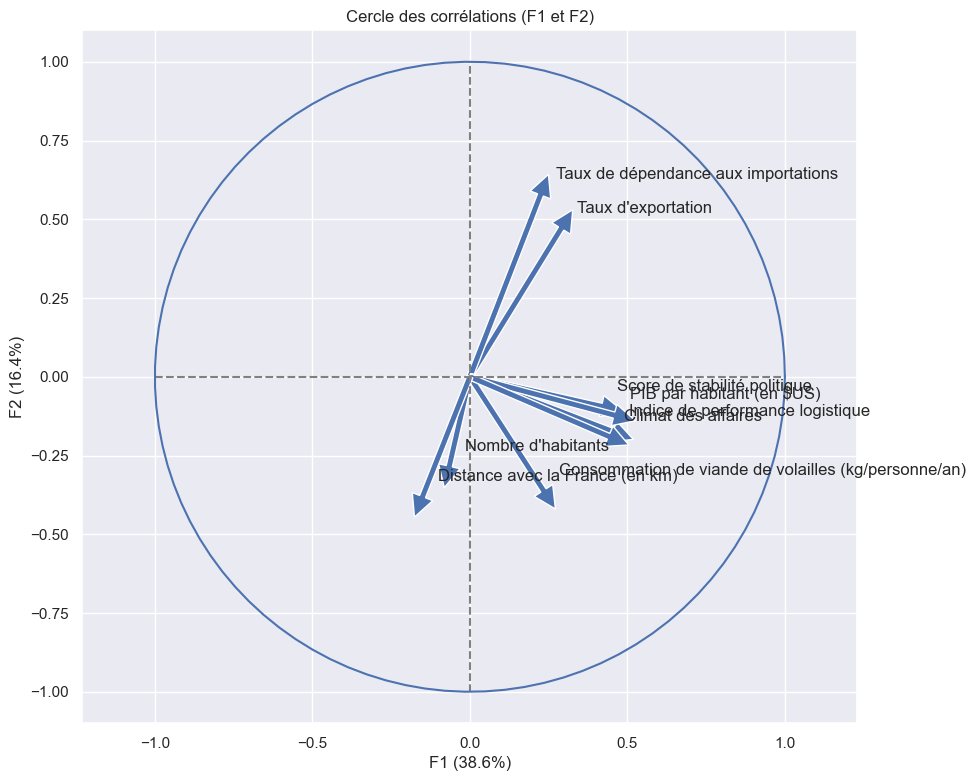

In [13]:
#Cercle des corrélations pour les composantes principales (F1 et F2)
correlation_graph(pca,(0,1),features)

Les variables les plus corrélées à F1 sont : 
- Score de stabilité politique
- PIB par habitant
- Indice de performance logistique
- Climat des affaires

Elles sont toutes les 4 corrélées positivement entre elles.
On pourrait donc qualifier cet axe de "Niveau de développement économique"

Les variables les plus corrélées à F2 sont : 
- Taux de dépendance aux importations
- Taux d'exportation

On pourrait donc qualifier cet axe de "Situation sur le marché de la viande de volailles"
Le point intéressant sur cet axe est que les 2 taux sont corrélées positivement entre eux, ce qui signifie qu'il existe des pays à la fois très importateurs et très exportateurs, qui pourraient être considérés comme des pays d'échanges commerciaux.

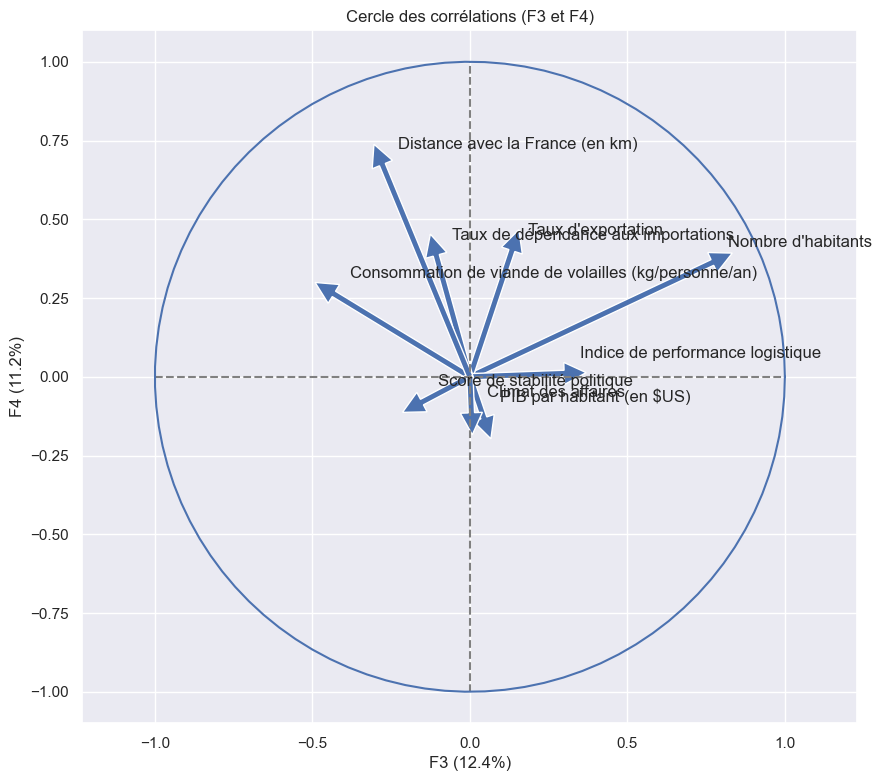

In [14]:
#Cercle des corrélations pour les composantes secondaires (F3 et F4)
correlation_graph(pca,(2,3),features)

Les variables les plus corrélées à F3 sont : 
- Nombre d'habitants
- Consommation de viande de volailles

Elles sont opposées sur l'axe, ce qui laisse supposer un lien entre une population importante et une faible consommation et inversement.
On pourrait nommer cet axe "Taille du marché VS consommation"

Les variables les plus corrélées à F4 sont : 
- Distance avec la France

On pourrait nommer cet axe "Proximité géographique avec la France"

### Projection des individus

In [15]:
#Fonction permettant d'afficher la projection des individus
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[10,8], 
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments : 
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments : 
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8] 
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On gère les labels
    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    # On vérifie la variable axis 
    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y )>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    # on définit x et y 
    x, y = x_y

    # Initialisation de la figure       
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters
 
    # Les points    
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha, 
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe 
    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y 
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) : 
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center') 

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

In [16]:
#Calcul des coordonnées des individus dans le nouvel espace
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[ 0.1402905 , -1.12967531, -0.26608084,  0.717686  ,  0.65691167,
         0.38130602,  0.15982234, -0.45044184,  1.14993396],
       [-0.49069412,  1.15048703, -0.29635684, -0.61949604, -0.26290513,
        -0.80379991, -0.82619992, -0.02390409, -0.09006968],
       [-1.98816132,  0.67578104,  0.69648433, -0.99835647,  0.43136635,
         0.08944575,  0.68718203,  0.30917296,  0.29975711],
       [ 2.68413382, -0.11648089,  1.05100894, -0.95379863, -0.03945984,
         0.02283905,  0.31683788, -0.27245919,  0.46474613],
       [-2.24104438,  1.37264446, -0.34912699,  0.58005685, -0.38383891,
        -1.01428466,  0.75561295,  0.26519147,  0.18122193]])

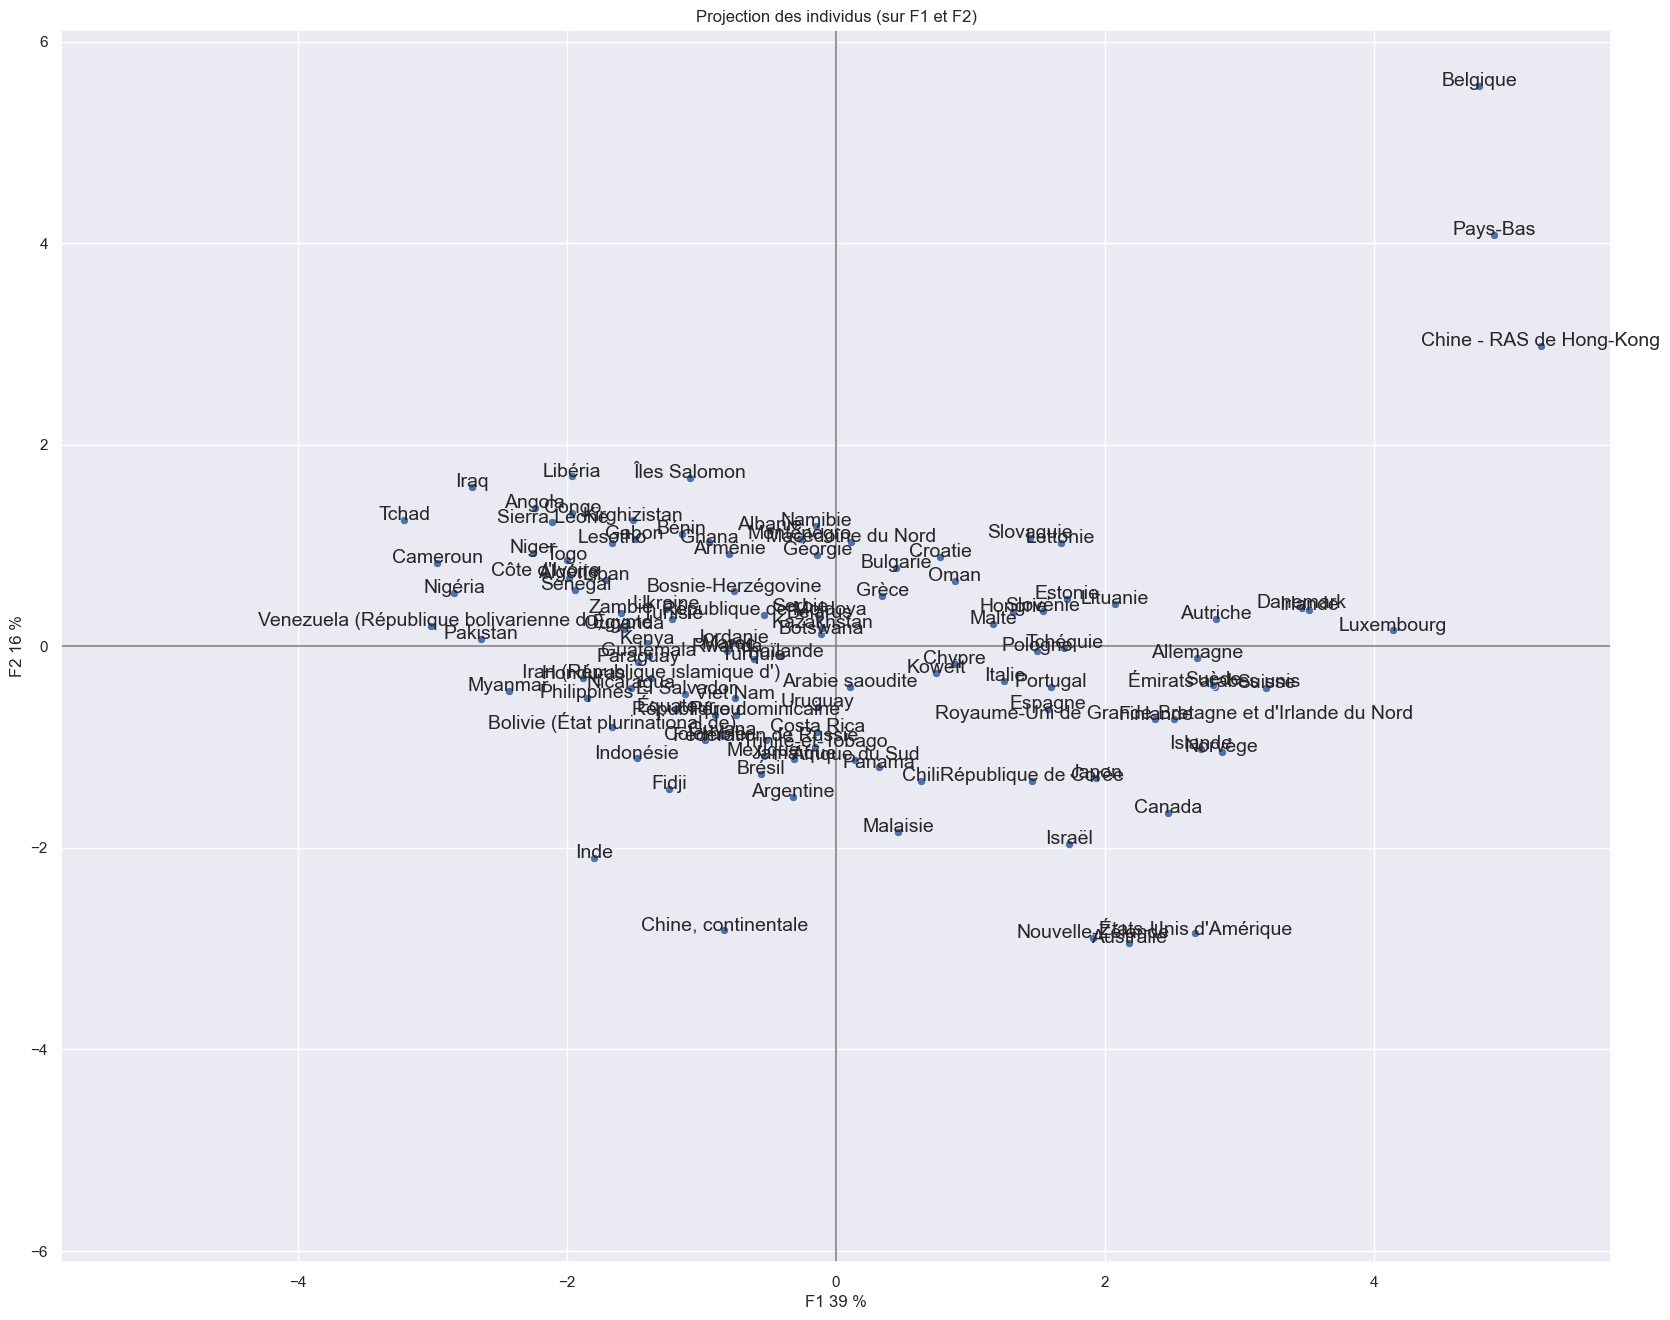

In [17]:
#Projection des individus sur plan factoriel F1 et F2
display_factorial_planes(X_proj, (0,1), pca, labels=names, figsize=(20,16), marker="o")

3 pays se détachent sur la projection des individus F1 et F2 : Belgique, Pays-Bas et Hong-Kong.

Ces pays ont à la fois un niveau de développement économique fort et sont très présents sur le marché de la viande de volailles au niveau mondial (import et export).

Le cadran en bas à droite regroupent les pays développés économiquement mais moins présents sur le marché international.

La partie gauche du graphe regroupent les pays moins développés économiquement.

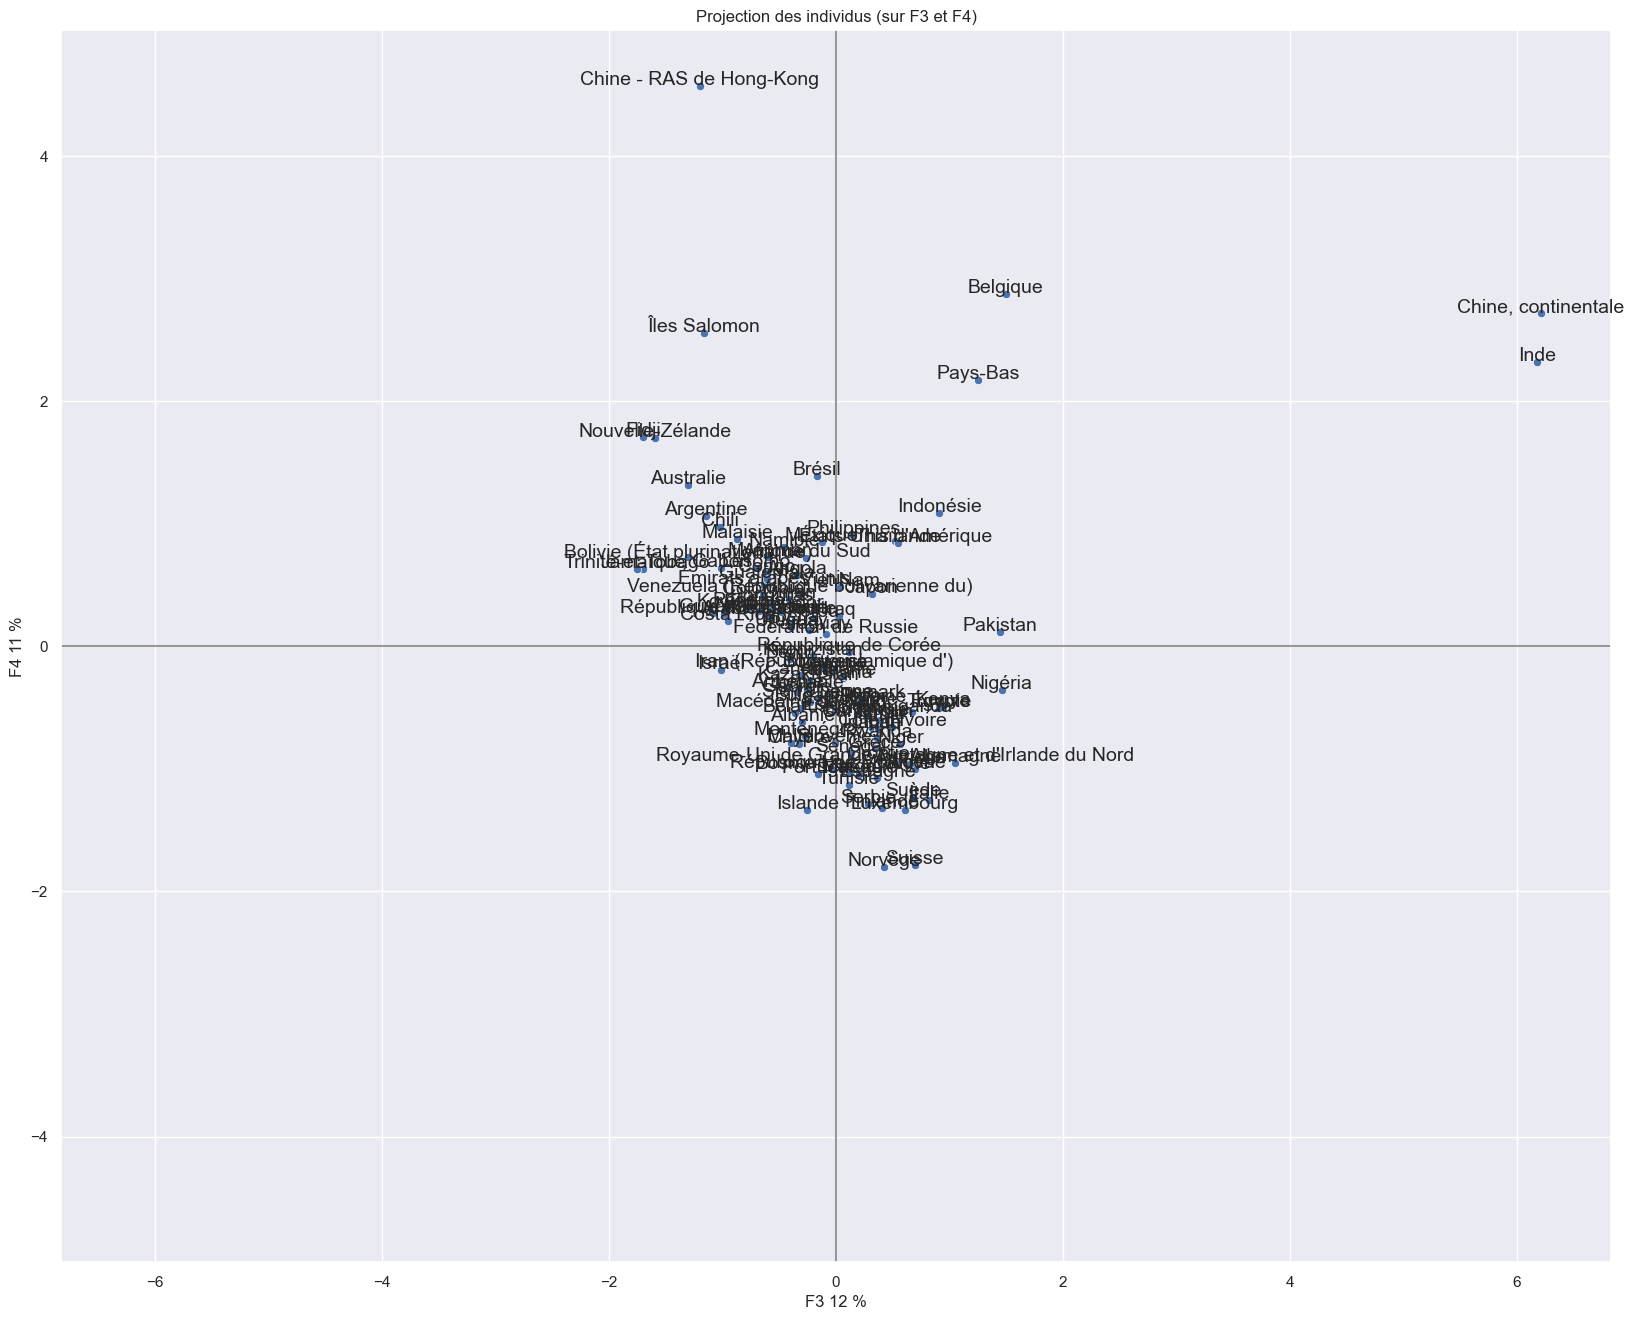

In [18]:
#Projection des individus sur plan factoriel F3 et F4
display_factorial_planes(X_proj, (2,3), pca, labels=names, figsize=(20,16), marker="o")

Les pays qui se détachent sur ce plan factoriel F3 et F4 sont : 
- Chine et Inde : avec un nombre d'habitants très élevé et moins consommateurs de viande de volailles, tout en étant plutôt distants de la France
- Hong-Kong : moins peuplé et plutôt consommateur de viande de volailles et très éloigné géographiquement de la France
- Belgique et Pays-Bas : moins peuplé et consommateurs moyens, tout en étant proches géographiquement de la France

## 2. Clustering

### K-means

In [19]:
#Création d'une liste vide pour enregistrer les inerties
inertia_list = []

#Liste de nombres de clusters
k_list = range(1,10)

#Pour chaque nombre de clusters
for k in k_list : 

    #on instancie un k-means
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)

    #On l'entraîne
    kmeans.fit(X_scaled)

    #On enregistre l'inertie obtenue
    inertia_list.append(kmeans.inertia_)

C:\Users\agnes\anaconda3\envs\Formation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\agnes\anaconda3\envs\Formation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\agnes\anaconda3\envs\Formation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\agnes\anaconda3\envs\Formation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

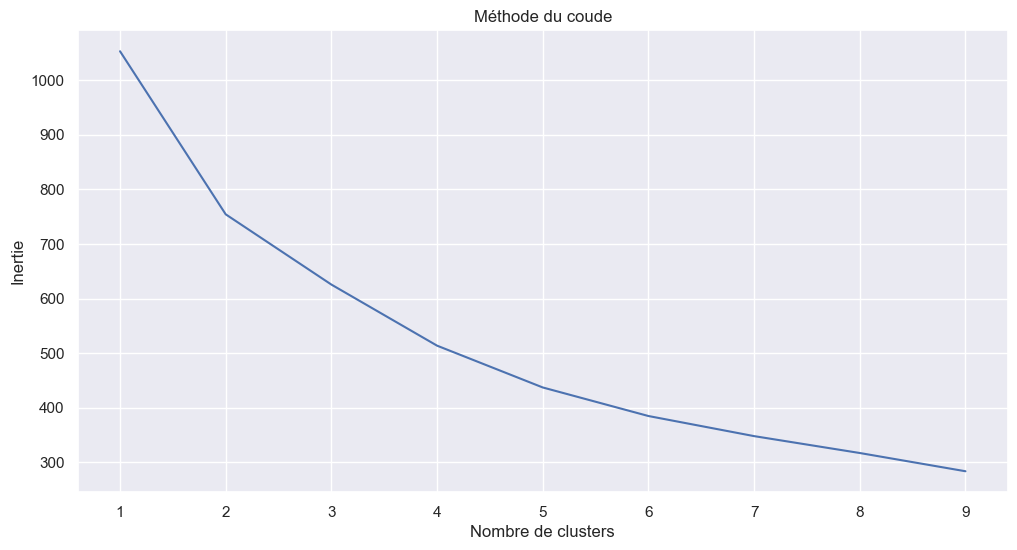

In [20]:
#Visualisation de l'inertie intraclasse obtenue en fonction du nombre de clusters
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("Inertie")
ax.set_xlabel("Nombre de clusters")
plt.title("Méthode du coude")
ax = plt.plot(k_list, inertia_list)

On peut utiliser la méthode du coude pour définir le nombre de clusters idéal pour nos données.
Ici, on considère que la cassure la plus forte se trouve à 2 clusters donc il s'agit du nombre idéal de clusters pour nos données.

Cependant, diviser les pays en seulement 2 groupes ne semblent pas pertinent d'un point de vue business. 

On peut voir une autre cassure intéressante pour 5 clusters donc on peut partir sur ce nombre pour notre étude.

### Classification hiérarchique ascendante

In [21]:
#calcul des distances avec matrice des distances, en général appelé Z
Z = linkage(X_scaled, method="ward")

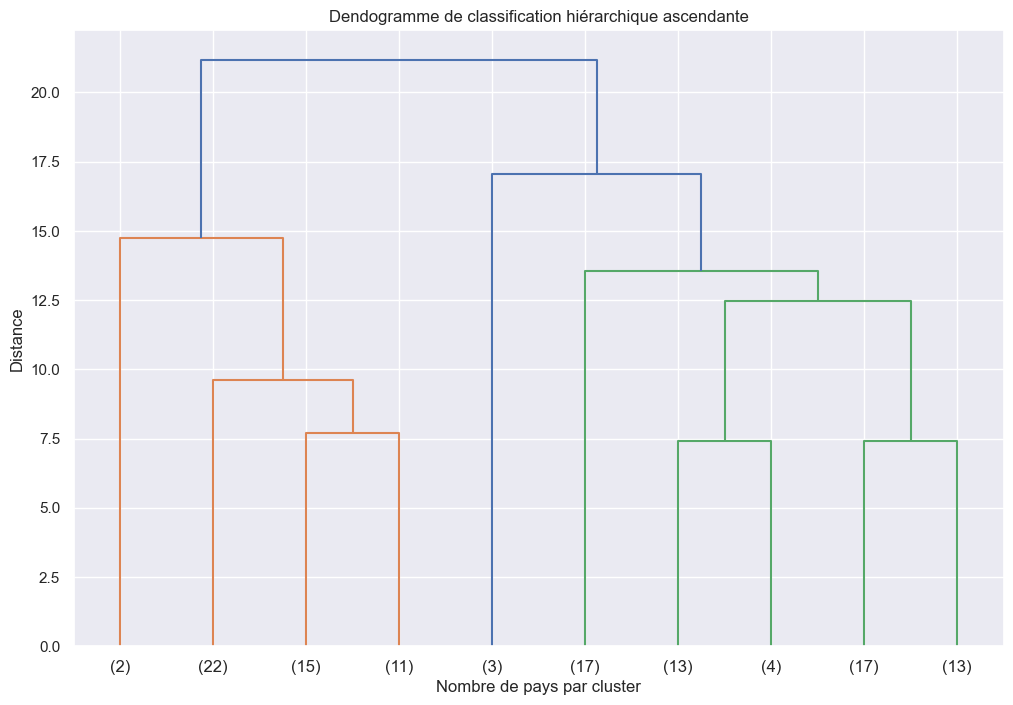

In [22]:
#Visualisation des clusters dans un dendogramme

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

#ici on spécifie qu'on ne veut voir que les 10 premiers clusters
_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)

plt.title("Dendogramme de classification hiérarchique ascendante")
plt.xlabel("Nombre de pays par cluster")
plt.ylabel("Distance")
plt.show()

On peut aussi appliquer la méthode du coude sur le dendogramme pour estimer le nombre de clusters idéal. Ici, la distance la plus importante entre 2 barres horizontales ferait couper 2 barres verticales, ce qui nous indique un nombre idéal de clusters de 2.
Cependant, d'un point de vue business, diviser tous les pays en seulement 2 groupes ne sera pas d'une grande aide au niveau business. On préfère donc conserver le nombre idéal de 5 clusters décidé avec le kmeans.

### Visualisation et analyse des clusters

In [23]:
#Calcul du kmeans avec 5 clusters

##Instanciation du Kmeans avec 5 clusters 
kmeans = KMeans(n_clusters=5, n_init=20, random_state=42)

##Entraînement 
kmeans.fit(X_scaled)

##Enregistrement des clusters dans une variable labels : 
labels = kmeans.labels_

C:\Users\agnes\anaconda3\envs\Formation\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


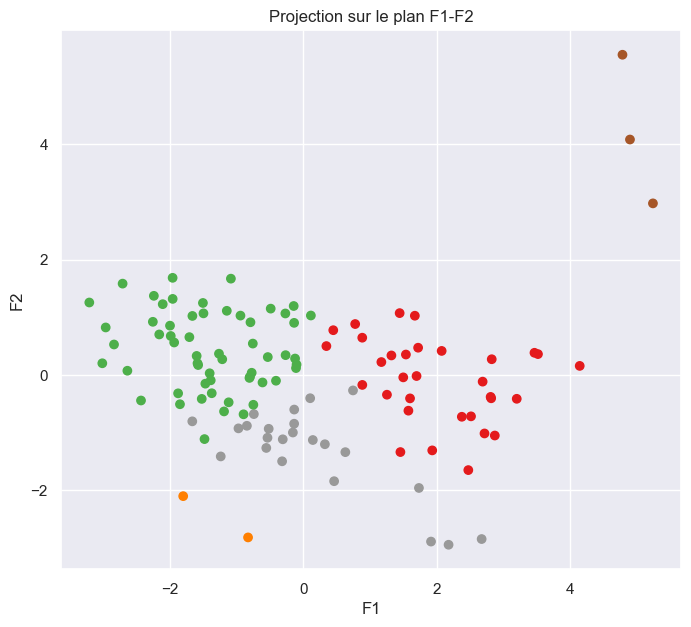

In [24]:
#Visualisation sur les plans factoriels F1 et F2 issus de l'ACP
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj[:, 0], X_proj[:, 1], c= labels, cmap="Set1")
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.title("Projection sur le plan F1-F2")
plt.show()

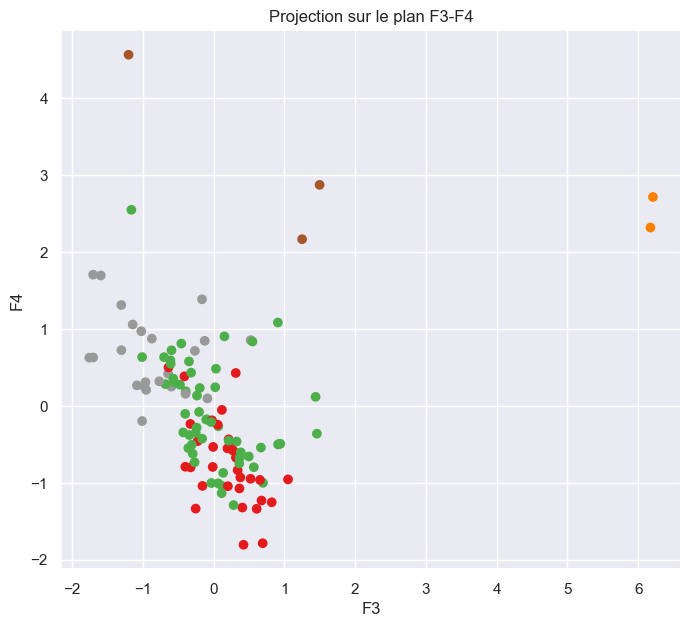

In [25]:
#Visualisation sur les plans factoriels F3 et F4 issus de l'ACP
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj[:, 2], X_proj[:, 3], c= labels, cmap="Set1")
ax.set_xlabel("F3")
ax.set_ylabel("F4")
plt.title("Projection sur le plan F3-F4")
plt.show()

In [26]:
# Ajout des étiquettes de clusters aux données d'origine avec les vraies valeurs (non centrées-réduites)
df_clusters = df.copy()
df_clusters['cluster'] = labels

# Calcul de la fiche d'identité moyenne de chaque groupe
df_clusters.groupby('cluster').mean()

,Nombre d'habitants,Consommation de viande de volailles (kg/personne/an),Taux d'exportation,Taux de dépendance aux importations,Score de stabilité politique,Indice de performance logistique,PIB par habitant (en $US),Climat des affaires,Distance avec la France (en km)
cluster,,,,,,,,,
0,2.004114e+07,23.392813,28.705625,48.582813,79.629492,3.617179,37710.666441,76.648918,2348.925066
1,3.408738e+07,12.904912,5.393860,34.393860,56.157494,2.601847,3670.191934,57.914095,5515.912449
2,1.379849e+09,7.275000,1.640000,1.245000,59.271862,3.540573,5464.890605,59.324865,7739.866900
3,1.191581e+07,28.830000,349.850000,236.580000,76.315196,4.121724,46569.811821,77.580867,3721.592509
4,4.858707e+07,39.341739,5.786957,13.738261,67.009426,3.024424,18583.239371,66.796199,9243.156161


Analyse des clusters :
- Cluster 0 (rouge) : pays avec niveau de développement économique élevé (PIB moyen 37k dollars) et situation moyenne sur le marché de la volaille (env 28% d'exportation et 48% de dépendance à l'importation) => intéressant pour l'entreprise
- Cluster 1 (vert) : pays moins développé économiquement (PIB plus faible 3K dollars et stabilité politique plus faible env 56) et situation moyenne sur le marché de la volaille (env 5% exportation et 34% de dépendance à l'importation) => peu intéressant pour l'entreprise
- Cluster 2 (orange) : Géants démographiques (1.3 milliards d'habitants en moy), peu consommateur de volaille (7 kg en moyenne) et surtout très peu présent sur le marché (1% env exportation et importation) => peu intéressant pour l'entreprise
- Cluster 3 (marron) : Situation très forte sur le marché (env 349% d'exportation et 236% de dépendance à l'importation), bon consommateur (28 kg environ) => très intéressant pour l'entreprise et à considérer comme hub logistique
- Cluster 4 (gris) : Population moyenne mais gros consommateur (env 39 kg), peu présent sur le marché (5% d'exportation et 13% de dépendance à l'importation en moyenne) et surtout très éloigné de la France (9000 km en moyenne) => peu intéressant pour l'entreprise

En conclusion, l'entreprise a plutôt intérêt à se concentrer sur les pays appartenant aux cluster 0 (rouge) et 3 (marron)

In [27]:
#Pays appartenant au cluster 0
df_clusters[df_clusters['cluster'] == 0].index.tolist()

['Allemagne',
 'Autriche',
 'Bulgarie',
 'Canada',
 'Chypre',
 'Croatie',
 'Danemark',
 'Émirats arabes unis',
 'Espagne',
 'Estonie',
 'Finlande',
 'Grèce',
 'Hongrie',
 'Irlande',
 'Islande',
 'Italie',
 'Japon',
 'Lettonie',
 'Lituanie',
 'Luxembourg',
 'Malte',
 'Norvège',
 'Oman',
 'Pologne',
 'Portugal',
 'République de Corée',
 "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
 'Slovaquie',
 'Slovénie',
 'Suède',
 'Suisse',
 'Tchéquie']

In [28]:
#Pays appartenant au cluster 1
df_clusters[df_clusters['cluster'] == 1].index.tolist()

['Albanie',
 'Algérie',
 'Angola',
 'Arménie',
 'Bélarus',
 'Bénin',
 'Bosnie-Herzégovine',
 'Botswana',
 'Cameroun',
 'Congo',
 "Côte d'Ivoire",
 'Égypte',
 'El Salvador',
 'Équateur',
 'Gabon',
 'Géorgie',
 'Ghana',
 'Guatemala',
 'Honduras',
 'Îles Salomon',
 'Indonésie',
 "Iran (République islamique d')",
 'Iraq',
 'Jordanie',
 'Kazakhstan',
 'Kenya',
 'Kirghizistan',
 'Lesotho',
 'Liban',
 'Libéria',
 'Macédoine du Nord',
 'Maroc',
 'Monténégro',
 'Myanmar',
 'Namibie',
 'Nicaragua',
 'Niger',
 'Nigéria',
 'Ouganda',
 'Pakistan',
 'Paraguay',
 'Pérou',
 'Philippines',
 'République de Moldova',
 'Rwanda',
 'Sénégal',
 'Serbie',
 'Sierra Leone',
 'Tchad',
 'Thaïlande',
 'Togo',
 'Tunisie',
 'Turquie',
 'Ukraine',
 'Venezuela (République bolivarienne du)',
 'Viet Nam',
 'Zambie']

In [29]:
#Pays appartenant au cluster 2
df_clusters[df_clusters['cluster'] == 2].index.tolist()

['Chine, continentale', 'Inde']

In [30]:
#Pays appartenant au cluster 3
df_clusters[df_clusters['cluster'] == 3].index.tolist()

['Belgique', 'Chine - RAS de Hong-Kong', 'Pays-Bas']

In [31]:
#Pays appartenant au cluster 4
df_clusters[df_clusters['cluster'] == 4].index.tolist()

['Afrique du Sud',
 'Arabie saoudite',
 'Argentine',
 'Australie',
 'Bolivie (État plurinational de)',
 'Brésil',
 'Chili',
 'Colombie',
 'Costa Rica',
 "États-Unis d'Amérique",
 'Fédération de Russie',
 'Fidji',
 'Guyana',
 'Israël',
 'Jamaïque',
 'Koweït',
 'Malaisie',
 'Mexique',
 'Nouvelle-Zélande',
 'Panama',
 'République dominicaine',
 'Trinité-et-Tobago',
 'Uruguay']

### Comparaison entre clusters obtenus avec k-means et classification hiérarchique ascendante

In [32]:
#Clustering avec classification hiérarchique ascendante forcé à 5 clusters (pour comparer avec les clusters du k-means)
cah_labels = fcluster(Z, t=5, criterion='maxclust')

In [33]:
#Création d'un dataframe qui compare le numéro de clusters attribué à chaque pays pour chaque méthode
df_comparaison = pd.DataFrame({'KMeans_Clusters': labels,'CAH_Clusters': cah_labels})
df_comparaison

,KMeans_Clusters,CAH_Clusters
0,4,5
1,1,5
2,1,2
3,0,4
4,1,2
...,...,...
112,1,5
113,4,2
114,1,2
115,1,2


In [34]:
#Création d'une matrice de comparaison pour analyser les clusters entre les 2 méthodes
pd.crosstab(df_comparaison['KMeans_Clusters'], df_comparaison['CAH_Clusters'])

CAH_Clusters,1,2,3,4,5
KMeans_Clusters,,,,,
0,0,0,0,17,15
1,0,42,0,0,15
2,2,0,0,0,0
3,0,0,3,0,0
4,0,6,0,0,17


Explications de la matrice : 
- Valeur 17 dans la ligne 0 et la colonne 4 : il y a 17 pays du cluster 0 du k-means classés dans le cluster 4 de la CAH
- Valeur 15 dans la ligne 0 et la colonne 5 : il y a 15 pays du cluster 0 du k-means classés dans le cluster 5 de la CAH

L'analyse de cette matrice nous montre que les 2 méthodes identifient bien les pays outliers (cluster 2 et 3 du k-means).
Par contre, il y a une différence de répartition pour les 3 autres clusters (même si on voit que le cluster 1 du k-means regroupe un nombre de pays en commun important avec le cluster 2 de la CAH => 42).

Pour cette étude, on privilégie les clusters choisis par la méthode du k-means. En effet, cette méthode a l'avantage d'être itérative, et donc qu'aucun pays ne soit figé dans un cluster dès le départ. Cela permet de créer des groupes plus équilibrés et qui répondent mieux à notre objectif.